In [1]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [2]:
#Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

df = pd.read_csv("winequality-red.csv")
print(df.shape)
print(df.head())

data = df.drop("quality", axis=1)

(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

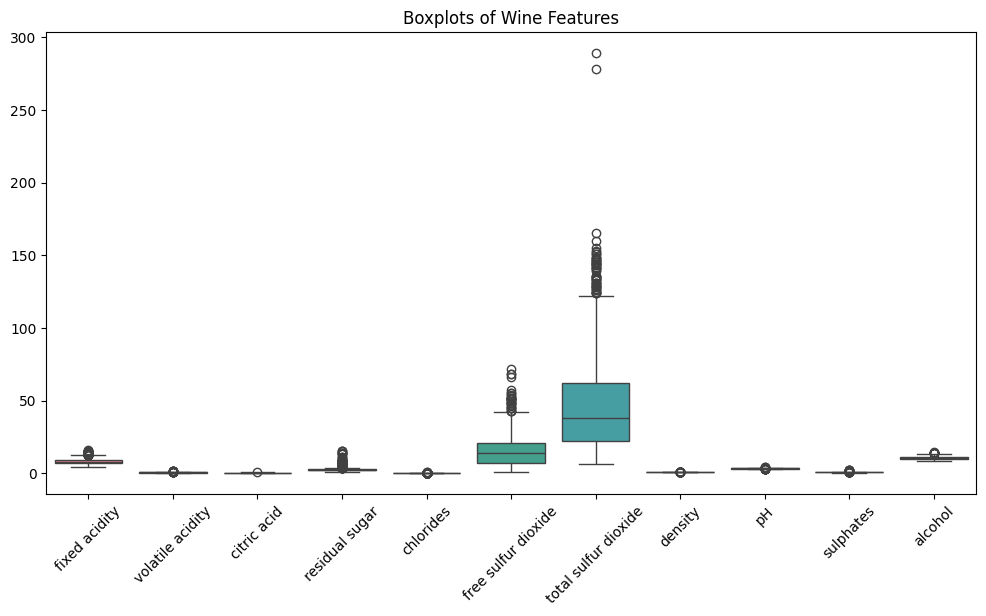

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplots of Wine Features")
plt.show()

black dots represents outliers

# Z-Score Method
Compares distance of a point from the mean in units of standard deviation.

Pros: Simple, fast, works well with normally distributed data.
Cons: Not reliable for skewed or non-normal distributions.

In [4]:
z_scores = np.abs(stats.zscore(data))
outliers_z = np.where(z_scores > 3)

print("Outlier positions (row, col):")
print(list(zip(outliers_z[0][:10], outliers_z[1][:10])))

Outlier positions (row, col):
[(np.int64(13), np.int64(9)), (np.int64(14), np.int64(5)), (np.int64(15), np.int64(5)), (np.int64(15), np.int64(6)), (np.int64(17), np.int64(4)), (np.int64(17), np.int64(9)), (np.int64(19), np.int64(4)), (np.int64(33), np.int64(3)), (np.int64(38), np.int64(1)), (np.int64(42), np.int64(4))]


# IQR Method (Interquartile Range)
Values too far below or above the “box” in a boxplot are flagged.

Pros: Robust to non-normal data, less influenced by extreme values.
Cons: Doesn’t adapt well to very skewed distributions.

In [5]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
dtype: int64


# Isolation Forest
Pros: Works well in high dimensions, efficient.
Cons: Requires choosing contamination (expected outlier fraction).

Randomly select features and split values.

Construct isolation trees.

Compute average path length for each point.

Shorter path = more likely outlier.

IsoForest_Outlier
 1    1519
-1      80
Name: count, dtype: int64


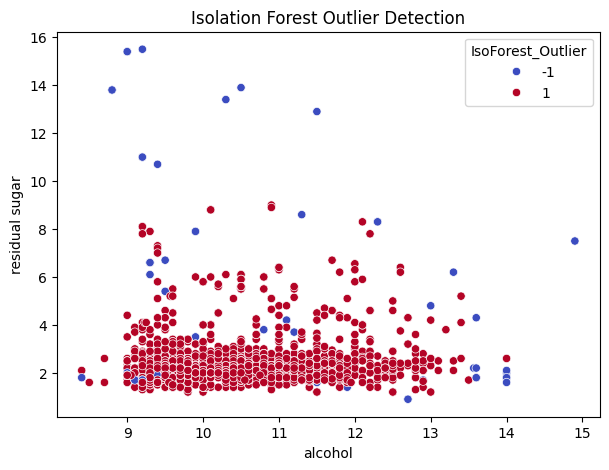

In [6]:
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(data)

df["IsoForest_Outlier"] = y_pred_iso
print(df["IsoForest_Outlier"].value_counts())

plt.figure(figsize=(7, 5))
sns.scatterplot(x="alcohol", y="residual sugar", data=df,
                hue="IsoForest_Outlier", palette="coolwarm")
plt.title("Isolation Forest Outlier Detection")
plt.show()

# Local Outlier Factor (LOF)
density-based anomaly detection technique that compares the local density of a data point to that of its neighbors.

Pros: Works well with clusters of varying density.

Cons: Sensitive to choice of k (neighbors).

For each point, find k-nearest neighbors.

Estimate local density based on neighbor distances.

Compare the density of the point with its neighbors.

If the point’s density ≪ neighbors → outlier.

LOF_Outlier
 1    1519
-1      80
Name: count, dtype: int64


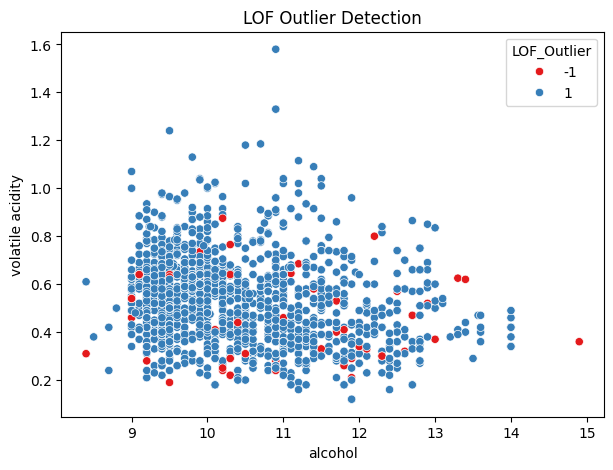

In [7]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(data)

df["LOF_Outlier"] = y_pred_lof
print(df["LOF_Outlier"].value_counts())

plt.figure(figsize=(7, 5))
sns.scatterplot(x="alcohol", y="volatile acidity",
                data=df, hue="LOF_Outlier", palette="Set1")
plt.title("LOF Outlier Detection")
plt.show()